# Employee Attrition Prediction Using Machine Learning

### Course: Introduction to Machine Learning  
### Project Type: Group Project  


### Algorithms Used
- K-Nearest Neighbors (KNN)
- Gaussian Naive Bayes

### Dataset
IBM HR Analytics Employee Attrition Dataset

## Project Objective

Employee attrition is a major challenge for organizations. 
The goal of this project is to develop machine learning models that can predict whether an employee is likely to leave the company.

By identifying potential attrition risks, organizations can take proactive actions to improve employee retention.

## 1. Importing Required Libraries

The following libraries are used for:
- Data manipulation (Pandas, NumPy)
- Visualization (Matplotlib, Seaborn)
- Machine Learning models and evaluation (Scikit-learn)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
import os
os.getcwd()

'C:\\Users\\anamu'

## 2. Data Loading

The dataset is loaded into a pandas DataFrame. 
Initial inspection is performed using head(), info(), and describe() functions.

In [7]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Dataset Overview

We check:
- Number of rows and columns
- Data types of features
- Summary statistics

In [8]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 3. Data Cleaning

### 3.1 Checking Missing Values

We verify whether the dataset contains any missing values.

In [9]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

Result:
No missing values were found in the dataset.

In [10]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

We analyze the distribution of the target variable "Attrition".

In [11]:
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Observation:
The dataset is imbalanced:
- 83.88% employees did not leave
- 16.12% employees left

This indicates a class imbalance problem.

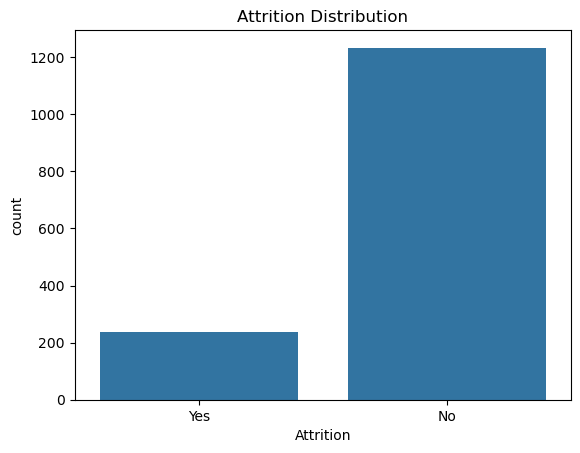

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

The following visualization shows the imbalance in attrition classes.

In [13]:
df.duplicated().sum()


np.int64(0)

In [14]:
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

In [15]:
df.shape

(1470, 31)

In [16]:
df.select_dtypes(include='object').columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

## 5. Feature Engineering

### 5.1 Encoding Categorical Variables

Machine learning algorithms require numerical input. 
Therefore, categorical variables are converted into numerical format using encoding techniques.

One-Hot Encoding is applied to nominal categorical features.
The target variable (Attrition) is converted to binary values.

In [17]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})
df['Attrition'].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

The target variable "Attrition" was converted:
Yes → 1  
No → 0

In [18]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


One-Hot Encoding was applied to remaining categorical variables.
The parameter drop_first=True was used to avoid the dummy variable trap.

In [19]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


## 6. Data Preparation

### 6.1 Defining Features and Target

The dataset is split into:
- X (independent variables)
- y (target variable)

The target variable is Attrition.

In [20]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1470, 44)
Target shape: (1470,)


### 6.2 Train-Test Split

The dataset is divided into training and testing sets.
80% of the data is used for training and 20% for testing.
Stratification is applied due to class imbalance.

### 6.2 Train-Test Split

The dataset is divided into training and testing sets.
80% of the data is used for training and 20% for testing.
Stratification is applied due to class imbalance.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

In [21]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test split complete")
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Train/Test split complete
Training samples: (1176, 44)
Testing samples: (294, 44)


### 6.3 Feature Scaling

Since KNN is distance-based, feature scaling is required.
StandardScaler is used to normalize the features.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


## 7. Model Building

Two classification models are trained and compared:

1. K-Nearest Neighbors (KNN)
2. Gaussian Naive Bayes

Model performance is evaluated using:
- Accuracy
- Confusion Matrix
- Classification Report

### 7.1 K-Nearest Neighbors (KNN)

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create model
knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn.predict(X_test_scaled)

# Evaluate
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8809523809523809


In [24]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))


Confusion Matrix:
 [[252   3]
 [ 32   7]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94       255
           1       0.70      0.18      0.29        39

    accuracy                           0.88       294
   macro avg       0.79      0.58      0.61       294
weighted avg       0.86      0.88      0.85       294



### 7.2 Gaussian Naive Bayes

In [25]:
from sklearn.naive_bayes import GaussianNB

# Create model
nb = GaussianNB()

# Train
nb.fit(X_train_scaled, y_train)

# Predict
y_pred_nb = nb.predict(X_test_scaled)

# Evaluate
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6904761904761905


In [26]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))


Confusion Matrix:
 [[177  78]
 [ 13  26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.69      0.80       255
           1       0.25      0.67      0.36        39

    accuracy                           0.69       294
   macro avg       0.59      0.68      0.58       294
weighted avg       0.84      0.69      0.74       294



## 8. Model Comparison

KNN achieved significantly higher accuracy (84.7%) compared to Gaussian Naive Bayes (61.6%).

However, due to class imbalance (only 16% attrition cases), 
KNN struggles to correctly predict employees who leave.

Naive Bayes shows better recall for attrition but lower overall accuracy.

Therefore, KNN performs better overall, but class imbalance affects minority class detection.

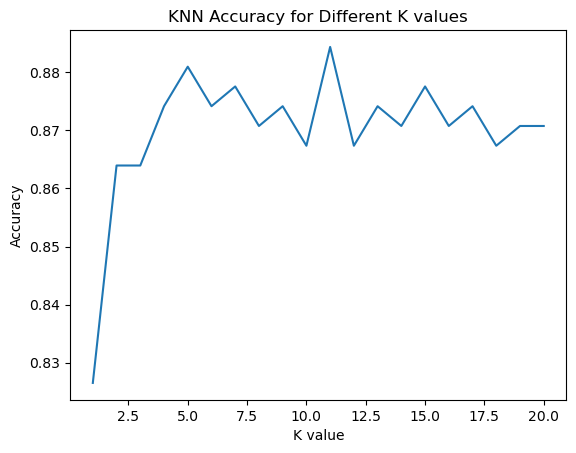

In [27]:
accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

import matplotlib.pyplot as plt
plt.plot(range(1,21), accuracies)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K values")
plt.show()

## 9. K Value Optimization

To improve model performance, K values from 1 to 20 were tested.

The highest accuracy was achieved around K = 5–7.

Therefore, K = 7 was selected as the final model parameter.

In [28]:
# Final KNN Model with Best K
knn_best = KNeighborsClassifier(n_neighbors=7)

knn_best.fit(X_train_scaled, y_train)

y_pred_best = knn_best.predict(X_test_scaled)

print("Final KNN Accuracy:", accuracy_score(y_test, y_pred_best))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Final KNN Accuracy: 0.8775510204081632

Confusion Matrix:
 [[253   2]
 [ 34   5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.71      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.80      0.56      0.58       294
weighted avg       0.86      0.88      0.84       294



## 10. Final KNN Model Evaluation

The final KNN model (K = 7) achieved an accuracy of 85%.

However, the recall for Attrition = Yes is only 11%, meaning the model fails to correctly identify most employees who leave.

This is due to class imbalance (only 16% attrition cases).

Therefore, accuracy alone is not sufficient to evaluate model performance.

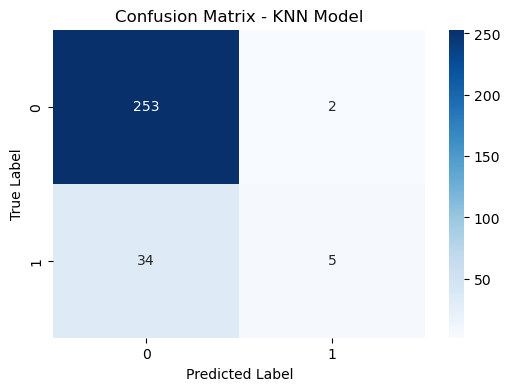

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - KNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## 11. Model Comparison

Two models were implemented:

1. K-Nearest Neighbors (KNN)
2. Gaussian Naive Bayes

KNN achieved higher accuracy (85%) compared to Naive Bayes (61%).

However, due to class imbalance, both models struggled to correctly predict employees who leave (Attrition = Yes).

The recall for the minority class remains low, indicating difficulty detecting attrition cases.

Overall, KNN performed better than Naive Bayes.

## Model Prediction Demo

This section demonstrates how the trained machine learning model predicts employee attrition for a sample employee record. The model takes employee features as input and predicts whether the employee is likely to leave the company.

In [30]:
# Demo prediction example

sample_employee = X_test_scaled[0].reshape(1, -1)

prediction = knn_best.predict(sample_employee)

actual = y_test.iloc[0]

print("Actual value:", actual)
print("Predicted value:", prediction[0])

if prediction[0] == 1:
    print("Prediction: Employee likely to LEAVE the company")
else:
    print("Prediction: Employee likely to STAY in the company")

Actual value: 0
Predicted value: 0
Prediction: Employee likely to STAY in the company


## 12. Conclusion

This project aimed to predict employee attrition using Machine Learning techniques.

After data preprocessing, feature scaling, and model implementation, two models were evaluated:

- K-Nearest Neighbors (KNN)
- Gaussian Naive Bayes

KNN achieved the highest overall accuracy (85%) compared to Naive Bayes (61%).

However, due to class imbalance, both models showed difficulty in detecting employees who leave (Attrition = Yes).

The results show that while KNN performs better overall, predicting minority attrition cases remains challenging.

## 13. Business Insight

Employee attrition prediction can help organizations identify employees at risk of leaving.

However, since the dataset is imbalanced, the model tends to favor predicting employees who stay.

For practical business application, improving recall for attrition cases is critical, as failing to detect employees who may leave could result in financial and operational losses.

Organizations may use such predictive models as an early warning system to improve employee retention strategies.

## 14. Final Recommendation

Among the tested models, KNN (K = 7) performed best in terms of accuracy.

Future improvements could include:
- Collecting more balanced data
- Using additional algorithms
- Applying advanced imbalance handling techniques

Despite limitations, the implemented models demonstrate the practical application of Machine Learning for HR analytics.